# Lab Task 02: Effect of Image Filtering on Skin-Lesion Classification (HAM10000)
**Runtime > Change runtime type > T4 GPU**, then **Runtime > Run all**.

Pipeline: load HAM10000 -> lesion-grouped stratified split -> 6 input variants (No filter, Average, Gaussian, Median, Sharpening, Sobel)
-> fine-tune 3 pretrained models on each (18 runs) -> metrics, confusion matrices, curves, ROC, per-class analysis -> answers.

**Edit only the CONFIG cell** (put your 3 best models from Lab 1 there).

In [1]:
%pip -q install kagglehub datasets

In [2]:
# ===================== CONFIG (EDIT HERE) =====================
# Best three pretrained models from Lab 1. Any torchvision classification model name works, e.g.:
# "resnet50", "resnet18", "densenet121", "efficientnet_b0", "vgg16", "mobilenet_v2", "convnext_tiny", "regnet_y_400mf"
MODEL_NAMES = ["resnet50", "densenet121", "efficientnet_b0"]

FILTERS = ["No Filter", "Average", "Gaussian", "Median", "Sharpening", "Sobel"]

IMG_SIZE       = 128     # 224 is more accurate but ~3x slower
EPOCHS         = 8
BATCH_SIZE     = 64
LR             = 1e-4
SEED           = 42
MAX_PER_CLASS  = None    # e.g. 400 for a quick subset (instructor-approved subset); None = full dataset
SELECTED_CLASSES = None  # None = all 7 classes, or e.g. ["nv","mel","bkl","bcc"]
OUT_DIR = "/content/lab02_results"
# ==============================================================

In [3]:
import os, random, time, pickle, glob, zipfile, warnings
import numpy as np, pandas as pd, cv2, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
warnings.filterwarnings("ignore")
os.makedirs(f"{OUT_DIR}/runs", exist_ok=True); os.makedirs(f"{OUT_DIR}/figs", exist_ok=True)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", dev, torch.cuda.get_device_name(0) if dev.type == "cuda" else "(no GPU: enable T4 for speed)")

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

Device: cuda Tesla T4


## 1. Load HAM10000 (Kaggle mirror, falls back to Hugging Face)

In [4]:
LESION_NAMES = {"akiec": "Actinic keratoses", "bcc": "Basal cell carcinoma", "bkl": "Benign keratosis",
                "df": "Dermatofibroma", "mel": "Melanoma", "nv": "Melanocytic nevi", "vasc": "Vascular lesions"}

def _read(p):
    im = cv2.imread(p)
    return cv2.resize(cv2.cvtColor(im, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def load_ham():
    try:
        import kagglehub
        root = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
        meta = pd.read_csv(glob.glob(f"{root}/**/HAM10000_metadata.csv", recursive=True)[0])
        paths = {os.path.basename(p)[:-4]: p for p in glob.glob(f"{root}/**/*.jpg", recursive=True)}
        meta = meta[meta.image_id.isin(paths)].reset_index(drop=True)
        with ThreadPoolExecutor(8) as ex:
            X = np.stack(list(ex.map(_read, [paths[i] for i in meta.image_id])))
        print("Loaded from Kaggle mirror")
        return meta[["image_id", "lesion_id", "dx"]], X
    except Exception as e:
        print("Kaggle route failed:", repr(e)[:150], "-> trying Hugging Face")
        from datasets import load_dataset, concatenate_datasets
        ds = load_dataset("marmal88/skin_cancer")
        d = concatenate_datasets([ds[k] for k in ds.keys()])
        rows, imgs, seen = [], [], set()
        for r in d:
            if r["image_id"] in seen: continue
            seen.add(r["image_id"])
            im = cv2.resize(np.array(r["image"].convert("RGB")), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
            imgs.append(im); rows.append((r["image_id"], r["lesion_id"], r["dx"]))
        return pd.DataFrame(rows, columns=["image_id", "lesion_id", "dx"]), np.stack(imgs)

meta, X = load_ham()
if SELECTED_CLASSES:
    keep = meta.dx.isin(SELECTED_CLASSES).values; meta, X = meta[keep].reset_index(drop=True), X[keep]
if MAX_PER_CLASS:
    idx = meta.groupby("dx", group_keys=False).apply(lambda g: g.sample(min(len(g), MAX_PER_CLASS), random_state=SEED)).index.values
    idx = np.sort(idx); meta, X = meta.iloc[idx].reset_index(drop=True), X[idx]
CLASSES = sorted(meta.dx.unique()); c2i = {c: i for i, c in enumerate(CLASSES)}
y = meta.dx.map(c2i).values; NC = len(CLASSES)
print(f"Total images: {len(meta)} | classes ({NC}): {CLASSES} | array {X.shape}")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Loaded from Kaggle mirror
Total images: 10015 | classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'] | array (10015, 128, 128, 3)


## 2. Class distribution

Class            Full name  Images     %
   nv     Melanocytic nevi    6705 66.95
  mel             Melanoma    1113 11.11
  bkl     Benign keratosis    1099 10.97
  bcc Basal cell carcinoma     514  5.13
akiec    Actinic keratoses     327  3.27
 vasc     Vascular lesions     142  1.42
   df       Dermatofibroma     115  1.15


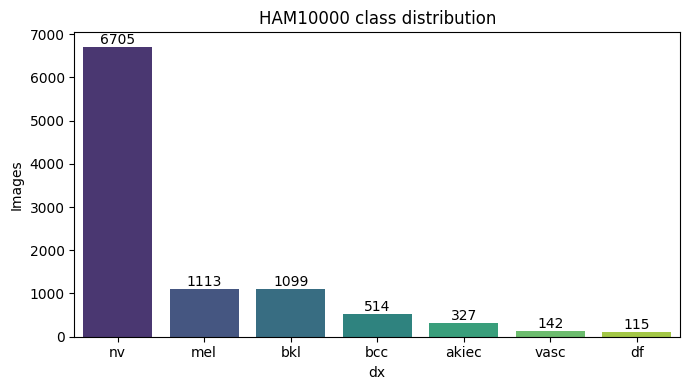

In [5]:
cnt = meta.dx.value_counts()
print(pd.DataFrame({"Class": cnt.index, "Full name": [LESION_NAMES[c] for c in cnt.index], "Images": cnt.values,
                    "%": (100 * cnt.values / cnt.sum()).round(2)}).to_string(index=False))
plt.figure(figsize=(7, 4)); ax = sns.barplot(x=cnt.index, y=cnt.values, palette="viridis")
for i, v in enumerate(cnt.values): ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("HAM10000 class distribution"); plt.ylabel("Images"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figs/class_distribution.png", dpi=150); plt.show()

## 3. Split (70/15/15, stratified, grouped by `lesion_id` so the same lesion never appears in two splits)

In [6]:
def make_split():
    sg = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
    rest, te = next(sg.split(np.zeros(len(y)), y, meta.lesion_id.values))
    sg2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
    a, b = next(sg2.split(np.zeros(len(rest)), y[rest], meta.lesion_id.values[rest]))
    return rest[a], rest[b], te
tr_idx, va_idx, te_idx = make_split()
for n, i in [("train", tr_idx), ("val", va_idx), ("test", te_idx)]:
    print(n, len(i), dict(zip(CLASSES, np.bincount(y[i], minlength=NC))))
assert not (set(meta.lesion_id[tr_idx]) & set(meta.lesion_id[te_idx])), "lesion leakage"

train 7145 {'akiec': np.int64(244), 'bcc': np.int64(358), 'bkl': np.int64(780), 'df': np.int64(79), 'mel': np.int64(814), 'nv': np.int64(4769), 'vasc': np.int64(101)}
val 1429 {'akiec': np.int64(49), 'bcc': np.int64(67), 'bkl': np.int64(151), 'df': np.int64(27), 'mel': np.int64(153), 'nv': np.int64(962), 'vasc': np.int64(20)}
test 1441 {'akiec': np.int64(34), 'bcc': np.int64(89), 'bkl': np.int64(168), 'df': np.int64(9), 'mel': np.int64(146), 'nv': np.int64(974), 'vasc': np.int64(21)}


## 4. Filters (spatial domain) and visual examples

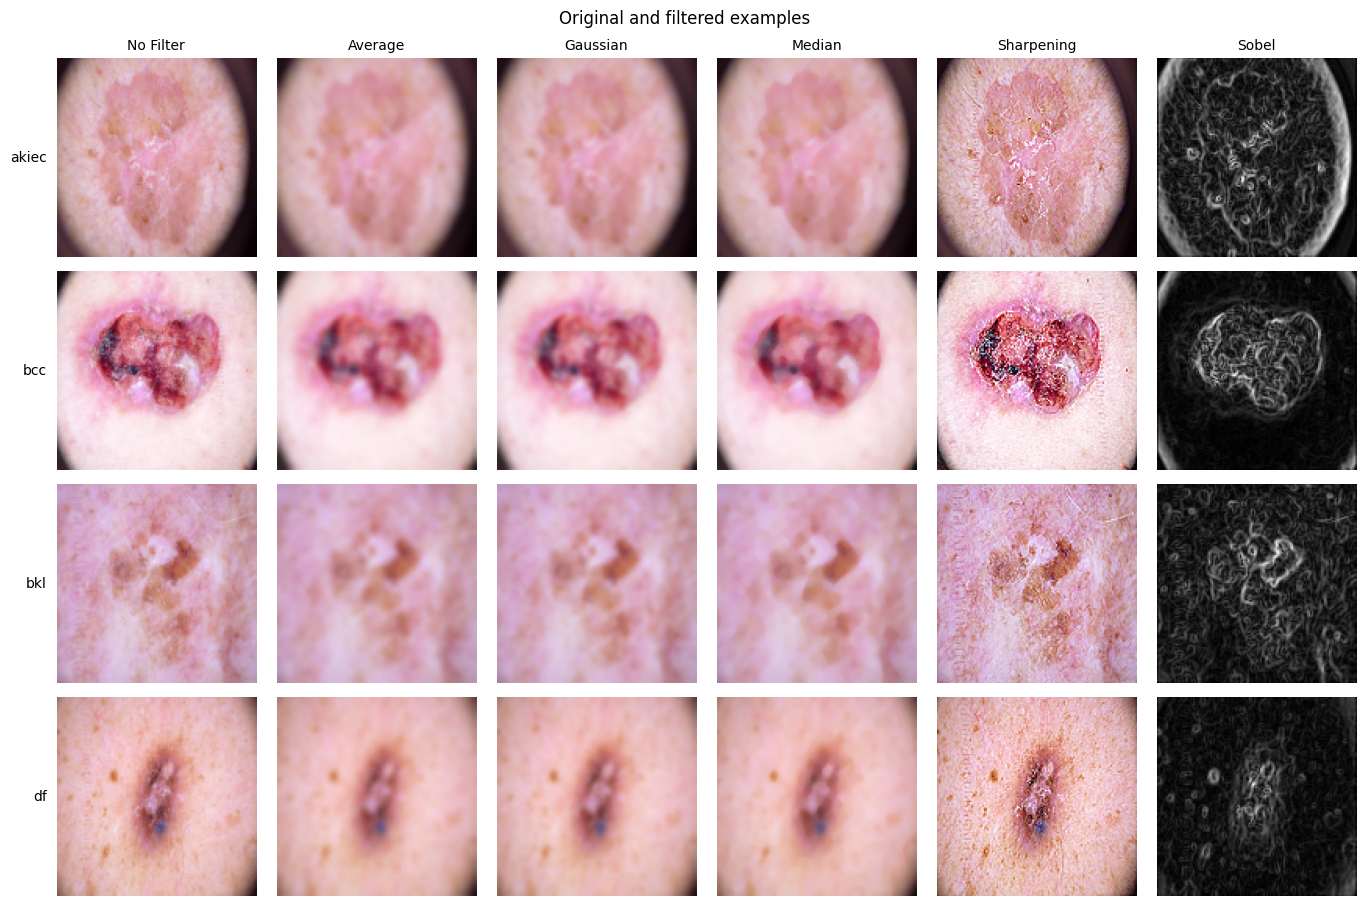

In [7]:
SHARP_K = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], np.float32)

def apply_filter(img, name):
    if name == "No Filter":  return img
    if name == "Average":    return cv2.blur(img, (5, 5))
    if name == "Gaussian":   return cv2.GaussianBlur(img, (5, 5), 1.5)
    if name == "Median":     return cv2.medianBlur(img, 5)
    if name == "Sharpening": return cv2.filter2D(img, -1, SHARP_K)
    if name == "Sobel":
        g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
        m = cv2.magnitude(cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3), cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3))
        m = np.clip(255 * m / (m.max() + 1e-6), 0, 255).astype(np.uint8)
        return np.stack([m] * 3, -1)
    raise ValueError(name)

def filter_all(Xa, name):
    return Xa if name == "No Filter" else np.stack([apply_filter(im, name) for im in Xa])

# examples: one image from each of up to 4 classes
ex_idx = [np.where(y == c)[0][0] for c in range(min(NC, 4))]
fig, axs = plt.subplots(len(ex_idx), len(FILTERS), figsize=(2.3 * len(FILTERS), 2.3 * len(ex_idx)))
axs = np.atleast_2d(axs)
for r, i in enumerate(ex_idx):
    for c, f in enumerate(FILTERS):
        axs[r, c].imshow(apply_filter(X[i], f)); axs[r, c].axis("off")
        if r == 0: axs[r, c].set_title(f, fontsize=10)
    axs[r, 0].text(-0.05, 0.5, CLASSES[y[i]], transform=axs[r, 0].transAxes, ha="right", va="center", fontsize=10)
plt.suptitle("Original and filtered examples"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figs/filter_examples.png", dpi=150); plt.show()

## 5. Model, training and evaluation (identical settings for every experiment)

In [8]:
import torchvision.models as tvm
MEAN = torch.tensor([0.485, 0.456, 0.406], device=dev).view(1, 3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225], device=dev).view(1, 3, 1, 1)

def build_model(name, nc):
    m = getattr(tvm, name)(weights="DEFAULT")
    if hasattr(m, "fc") and isinstance(m.fc, nn.Linear):
        m.fc = nn.Linear(m.fc.in_features, nc)
    elif isinstance(m.classifier, nn.Linear):
        m.classifier = nn.Linear(m.classifier.in_features, nc)
    else:
        for i in range(len(m.classifier) - 1, -1, -1):
            if isinstance(m.classifier[i], nn.Linear):
                m.classifier[i] = nn.Linear(m.classifier[i].in_features, nc); break
    return m.to(dev)

def prep(xb, train=False):
    xb = xb.permute(0, 3, 1, 2).float() / 255.0
    if train:
        B = xb.shape[0]
        for d in (3, 2):
            m = (torch.rand(B, device=dev) < 0.5).view(B, 1, 1, 1)
            xb = torch.where(m, xb.flip(d), xb)
    return (xb - MEAN) / STD

@torch.no_grad()
def predict(model, Xt, yt, idx):
    model.eval(); P, loss = [], 0.0
    for i in range(0, len(idx), 256):
        b = idx[i:i + 256]
        with torch.autocast(dev.type, enabled=dev.type == "cuda"):
            out = model(prep(Xt[b]))
        loss += F.cross_entropy(out.float(), yt[b], reduction="sum").item()
        P.append(F.softmax(out.float(), 1).cpu().numpy())
    return np.concatenate(P), loss / len(idx)

def metrics(yt, P):
    pr = P.argmax(1); Pn = P / P.sum(1, keepdims=True)
    try: auc = roc_auc_score(yt, Pn, multi_class="ovr", average="macro", labels=list(range(NC)))
    except Exception: auc = np.nan
    return dict(Accuracy=accuracy_score(yt, pr),
                Precision=precision_score(yt, pr, average="weighted", zero_division=0),
                Recall=recall_score(yt, pr, average="weighted", zero_division=0),
                F1=f1_score(yt, pr, average="weighted", zero_division=0),
                MacroF1=f1_score(yt, pr, average="macro", zero_division=0),
                BalancedAcc=balanced_accuracy_score(yt, pr), AUC=auc)

def run_experiment(model_name, filt, Xt, yt):
    path = f"{OUT_DIR}/runs/{model_name}__{filt.replace(' ', '_')}.pkl"
    if os.path.exists(path): return pickle.load(open(path, "rb"))     # resume support
    set_seed(SEED)
    model = build_model(model_name, NC)
    cw = torch.tensor(len(tr_idx) / (NC * np.bincount(y[tr_idx], minlength=NC).clip(1)), dtype=torch.float32, device=dev)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    steps = EPOCHS * int(np.ceil(len(tr_idx) / BATCH_SIZE))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=steps)
    scaler = torch.cuda.amp.GradScaler(enabled=dev.type == "cuda")
    tr_t, va_t, te_t = [torch.tensor(i, device=dev) for i in (tr_idx, va_idx, te_idx)]
    hist = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc", "val_macroF1"]}
    best, best_state, best_ep = -1, None, 0
    for ep in range(EPOCHS):
        model.train(); perm = tr_t[torch.randperm(len(tr_t), device=dev)]; tl = tc = 0
        for i in range(0, len(perm), BATCH_SIZE):
            b = perm[i:i + BATCH_SIZE]
            with torch.autocast(dev.type, enabled=dev.type == "cuda"):
                out = model(prep(Xt[b], True)); loss = crit(out.float(), yt[b])
            opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            tl += loss.item() * len(b); tc += (out.argmax(1) == yt[b]).sum().item()
        Pv, vl = predict(model, Xt, yt, va_t)
        vy = y[va_idx]; vf1 = f1_score(vy, Pv.argmax(1), average="macro", zero_division=0)
        hist["train_loss"].append(tl / len(tr_t)); hist["train_acc"].append(tc / len(tr_t))
        hist["val_loss"].append(vl); hist["val_acc"].append(accuracy_score(vy, Pv.argmax(1))); hist["val_macroF1"].append(vf1)
        if vf1 > best:
            best, best_ep = vf1, ep; best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)                                    # best epoch by validation macro-F1
    Pt, _ = predict(model, Xt, yt, te_t); yte = y[te_idx]
    rep = classification_report(yte, Pt.argmax(1), target_names=CLASSES, output_dict=True, zero_division=0)
    Pn = Pt / Pt.sum(1, keepdims=True)
    pc_auc = {}
    for c in range(NC):
        try: pc_auc[CLASSES[c]] = roc_auc_score((yte == c).astype(int), Pn[:, c])
        except Exception: pc_auc[CLASSES[c]] = np.nan
    res = dict(model=model_name, filter=filt, metrics=metrics(yte, Pt), per_class=rep, per_class_auc=pc_auc,
               cm=confusion_matrix(yte, Pt.argmax(1), labels=range(NC)), hist=hist, best_epoch=best_ep + 1, y_true=yte, probs=Pn)
    pickle.dump(res, open(path, "wb"))
    del model, opt; torch.cuda.empty_cache()
    return res

def show_run(r):
    fig, ax = plt.subplots(1, 4, figsize=(21, 4.2)); h = r["hist"]; e = range(1, len(h["train_acc"]) + 1)
    ax[0].plot(e, h["train_acc"], "o-", label="train"); ax[0].plot(e, h["val_acc"], "s-", label="val")
    ax[0].axvline(r["best_epoch"], ls=":", c="gray"); ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
    ax[1].plot(e, h["train_loss"], "o-", label="train"); ax[1].plot(e, h["val_loss"], "s-", label="val")
    ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[2], cbar=False)
    ax[2].set_title("Confusion matrix (test)"); ax[2].set_xlabel("Predicted"); ax[2].set_ylabel("True")
    for c in range(NC):
        if (r["y_true"] == c).any():
            fpr, tpr, _ = roc_curve((r["y_true"] == c).astype(int), r["probs"][:, c]); ax[3].plot(fpr, tpr, label=CLASSES[c])
    ax[3].plot([0, 1], [0, 1], "k--"); ax[3].set_title(f"ROC (macro AUC={r['metrics']['AUC']:.3f})"); ax[3].legend(fontsize=7)
    fig.suptitle(f"{r['model']} | {r['filter']} | best epoch {r['best_epoch']}"); plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/figs/{r['model']}__{r['filter'].replace(' ', '_')}.png", dpi=120); plt.show()

## 6. Run all experiments (3 models x 6 filters = 18 runs; results are cached, so re-running resumes where it stopped)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 95.1MB/s]


[01/18] resnet50         No Filter  acc=0.7800 macroF1=0.6042 balAcc=0.6402 AUC=0.9315 (78s)


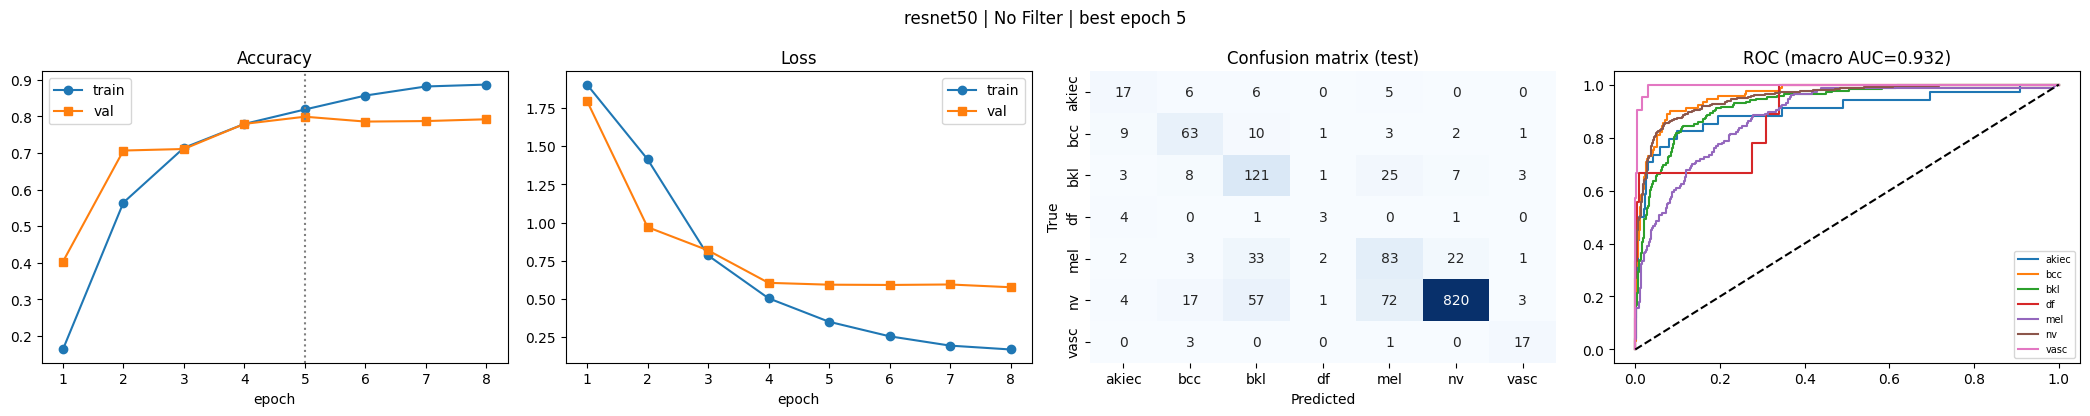

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 164MB/s]


[02/18] densenet121      No Filter  acc=0.7696 macroF1=0.6673 balAcc=0.7061 AUC=0.9424 (100s)


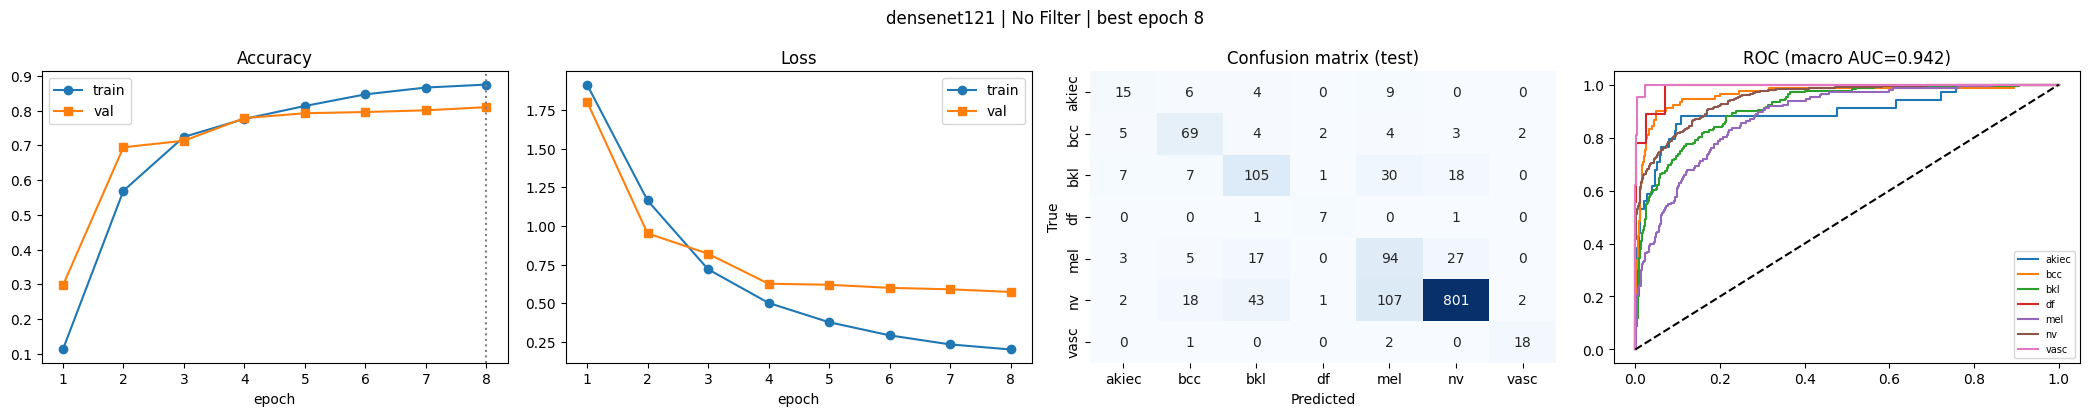

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 155MB/s]


[03/18] efficientnet_b0  No Filter  acc=0.7092 macroF1=0.5398 balAcc=0.6494 AUC=0.9161 (113s)


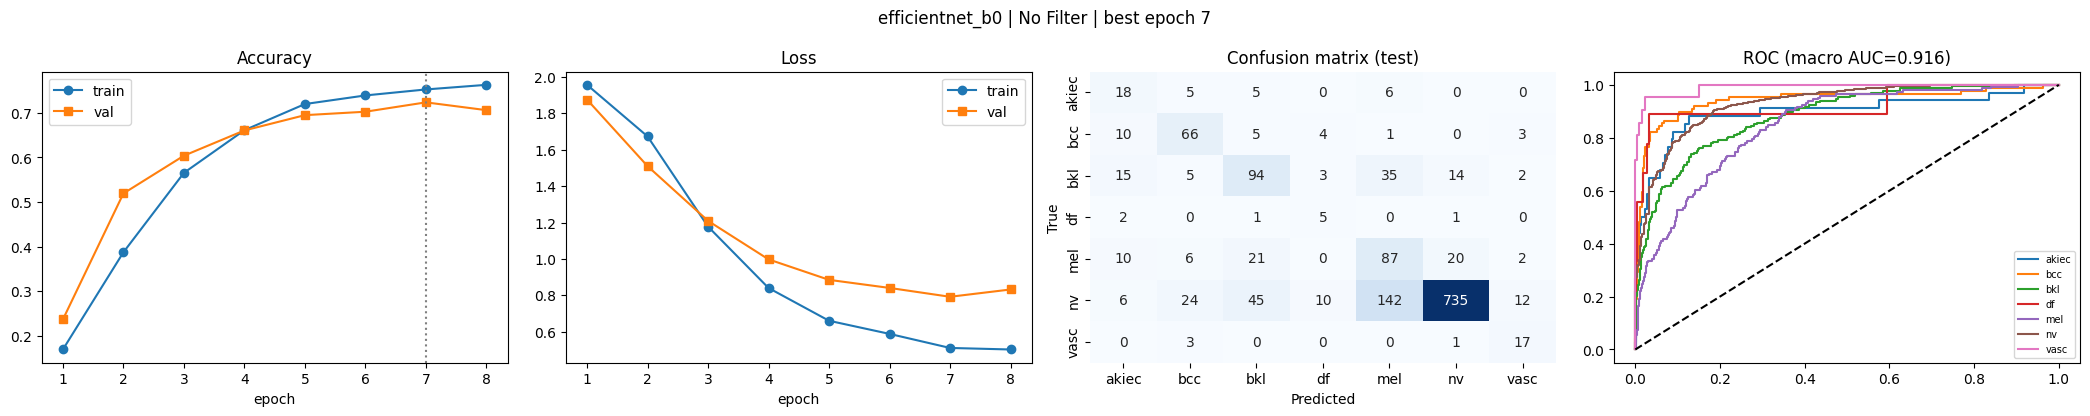

[04/18] resnet50         Average    acc=0.7550 macroF1=0.6103 balAcc=0.6542 AUC=0.9287 (78s)


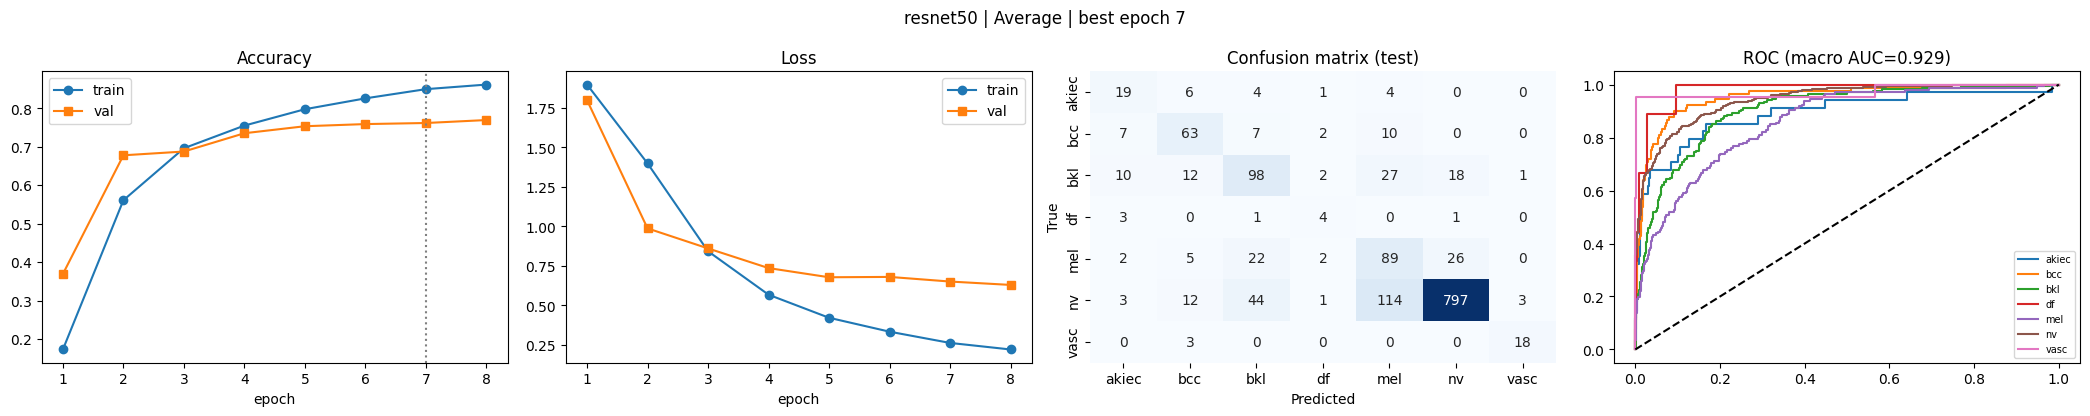

[05/18] densenet121      Average    acc=0.7273 macroF1=0.5917 balAcc=0.6719 AUC=0.9330 (98s)


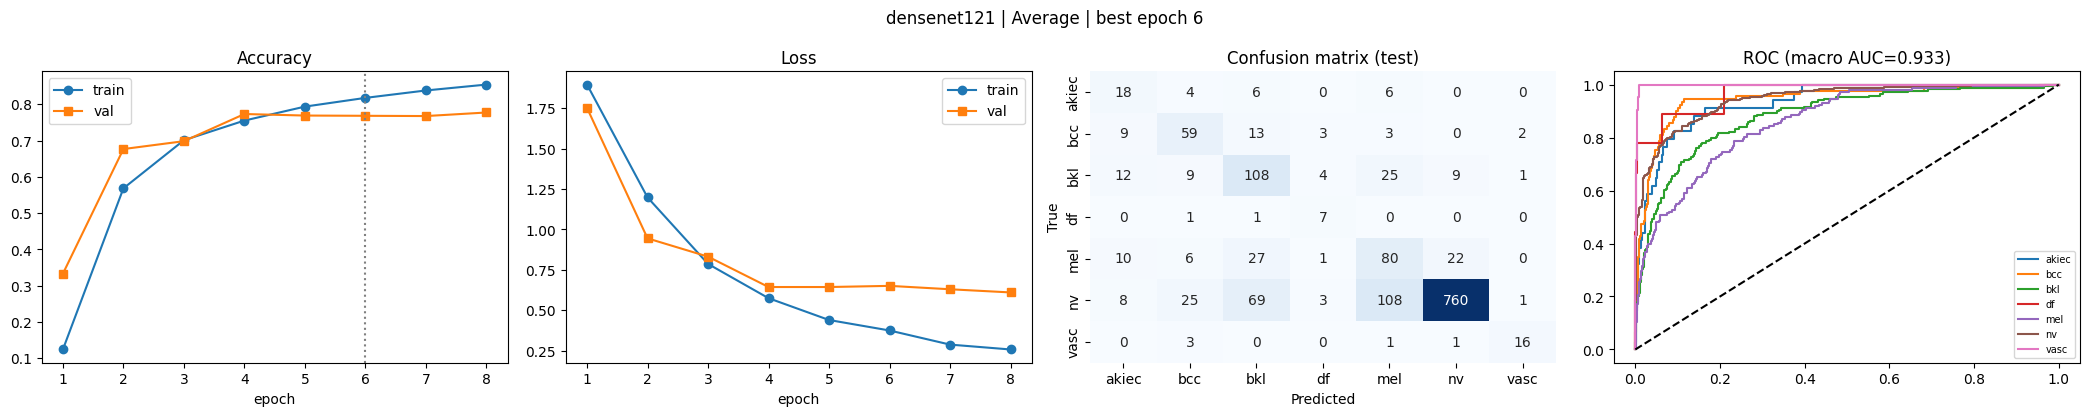

[06/18] efficientnet_b0  Average    acc=0.6995 macroF1=0.5230 balAcc=0.6243 AUC=0.9098 (54s)


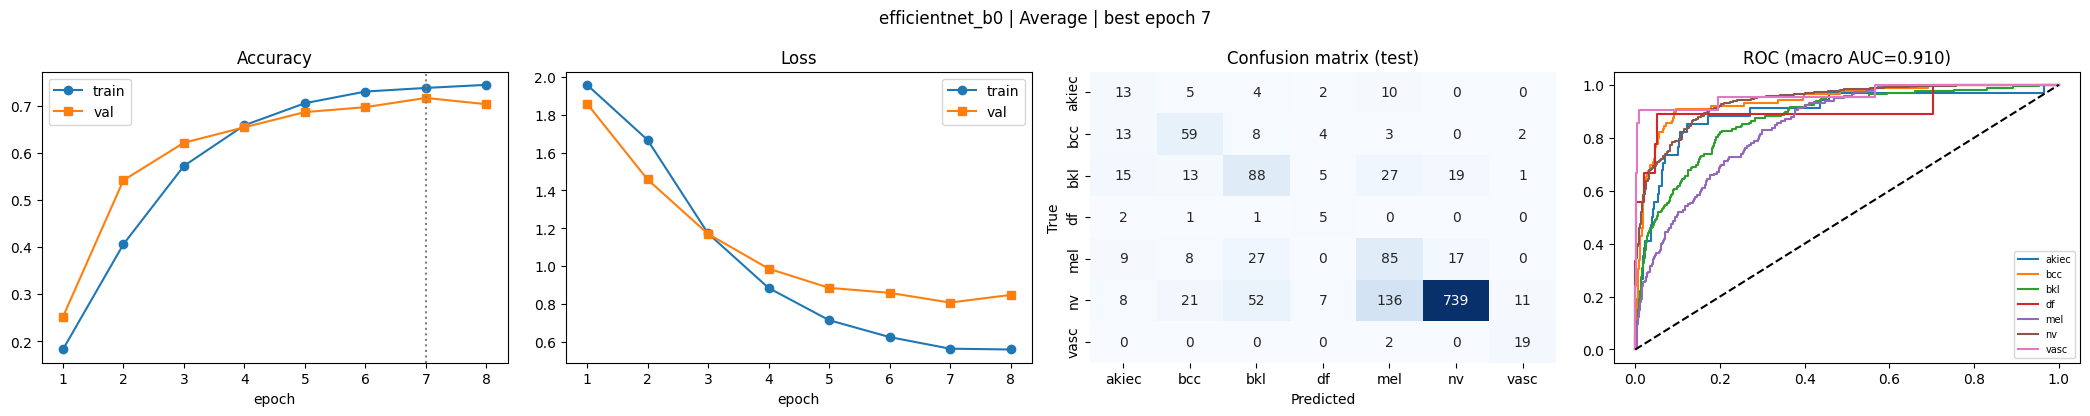

[07/18] resnet50         Gaussian   acc=0.7647 macroF1=0.6117 balAcc=0.6421 AUC=0.9292 (78s)


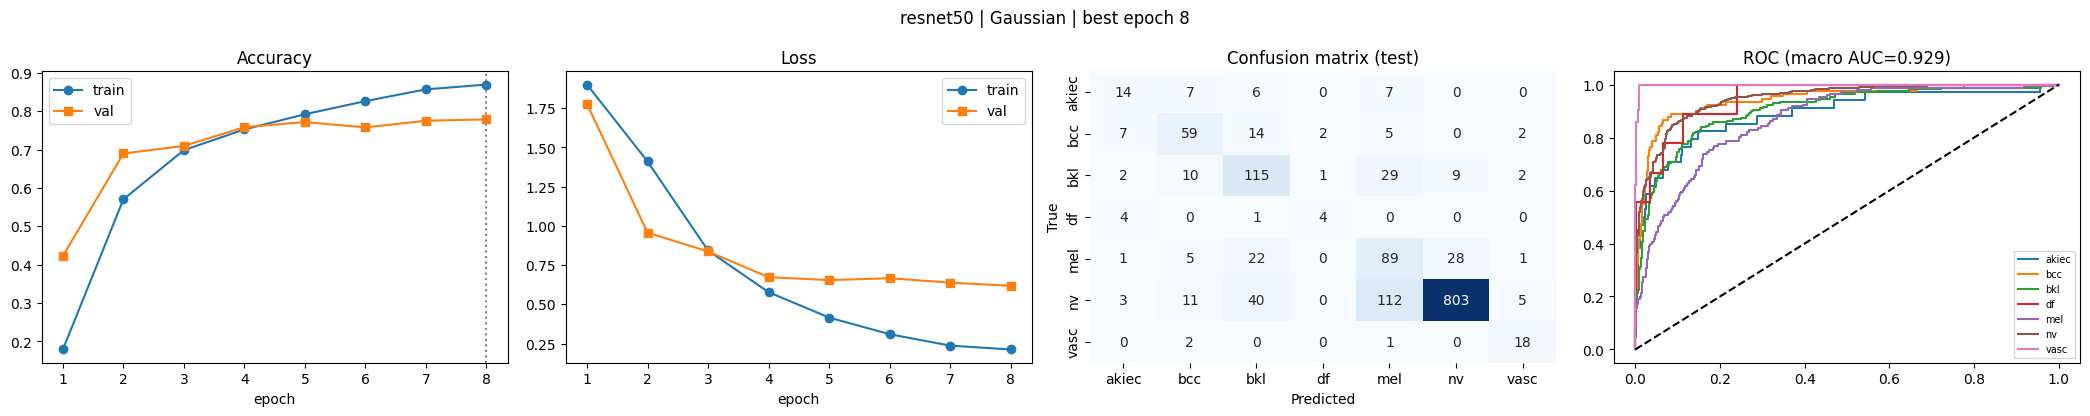

[08/18] densenet121      Gaussian   acc=0.7495 macroF1=0.6359 balAcc=0.6949 AUC=0.9297 (98s)


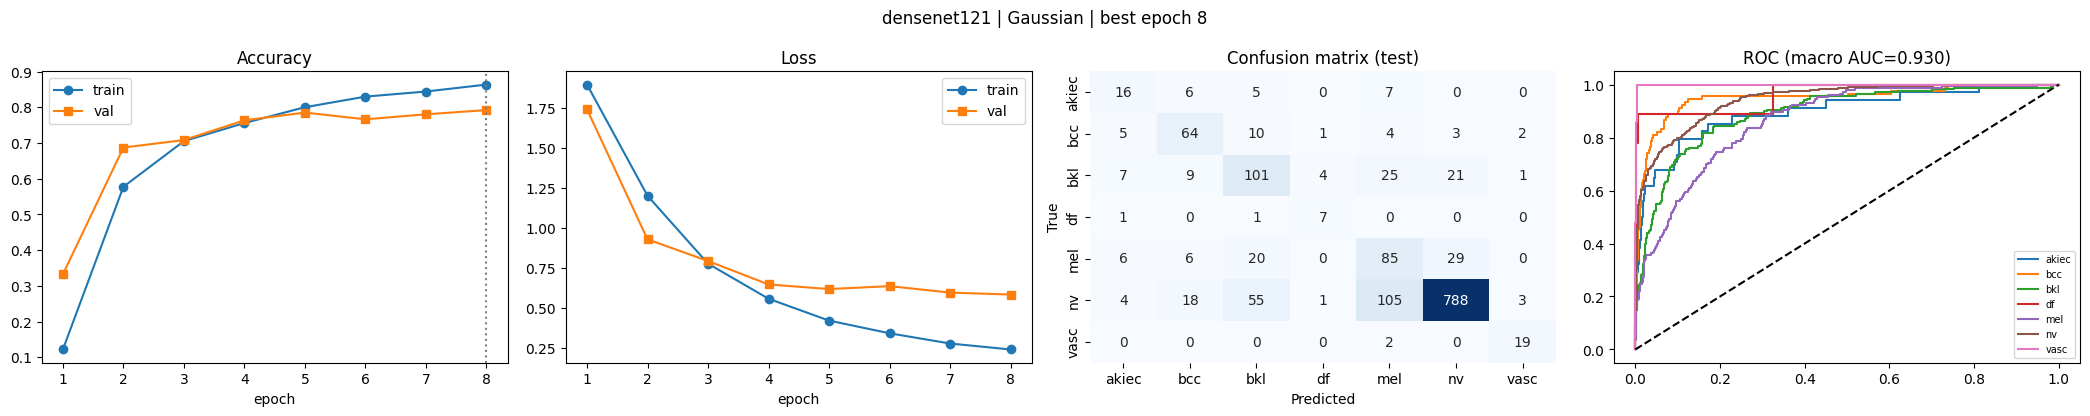

[09/18] efficientnet_b0  Gaussian   acc=0.6773 macroF1=0.5218 balAcc=0.6269 AUC=0.9035 (54s)


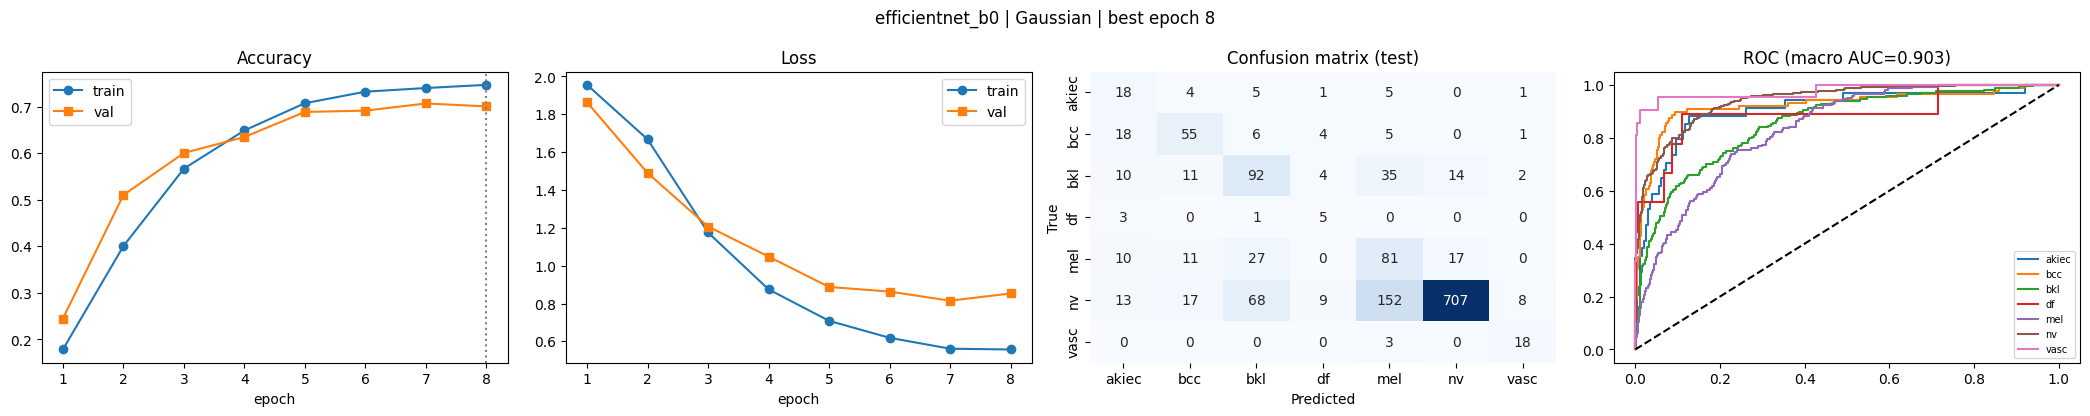

[10/18] resnet50         Median     acc=0.7585 macroF1=0.6465 balAcc=0.6730 AUC=0.9281 (78s)


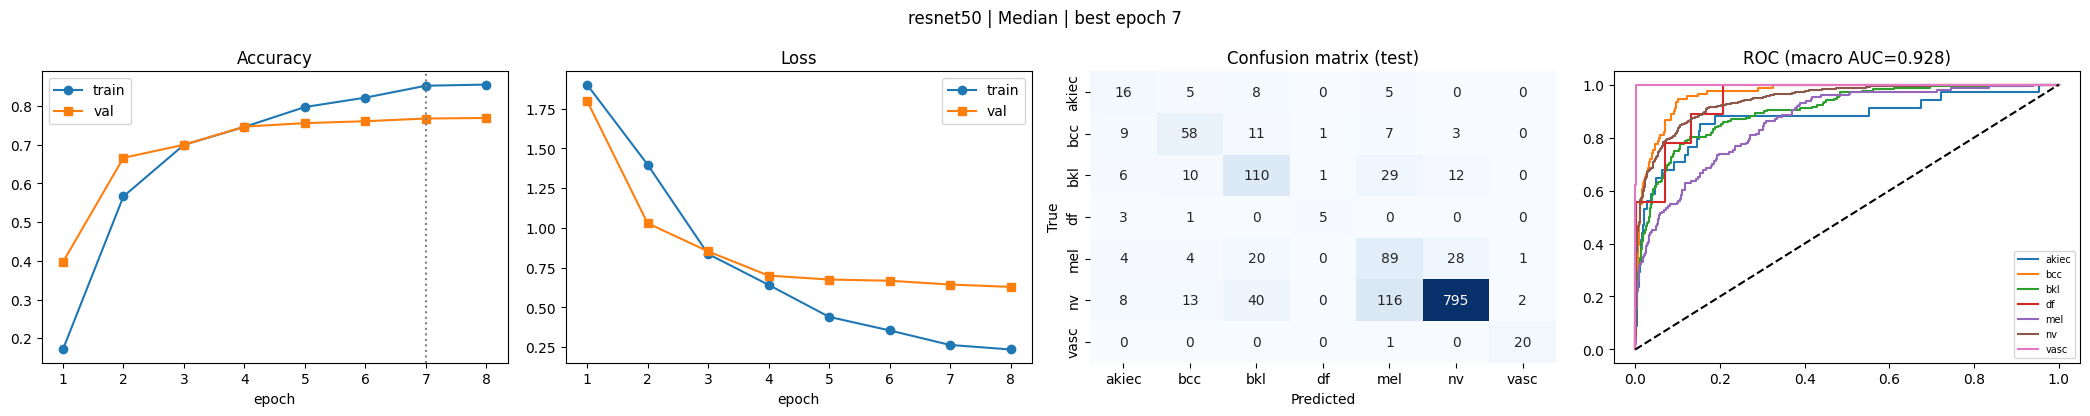

[11/18] densenet121      Median     acc=0.7550 macroF1=0.6437 balAcc=0.6832 AUC=0.9378 (99s)


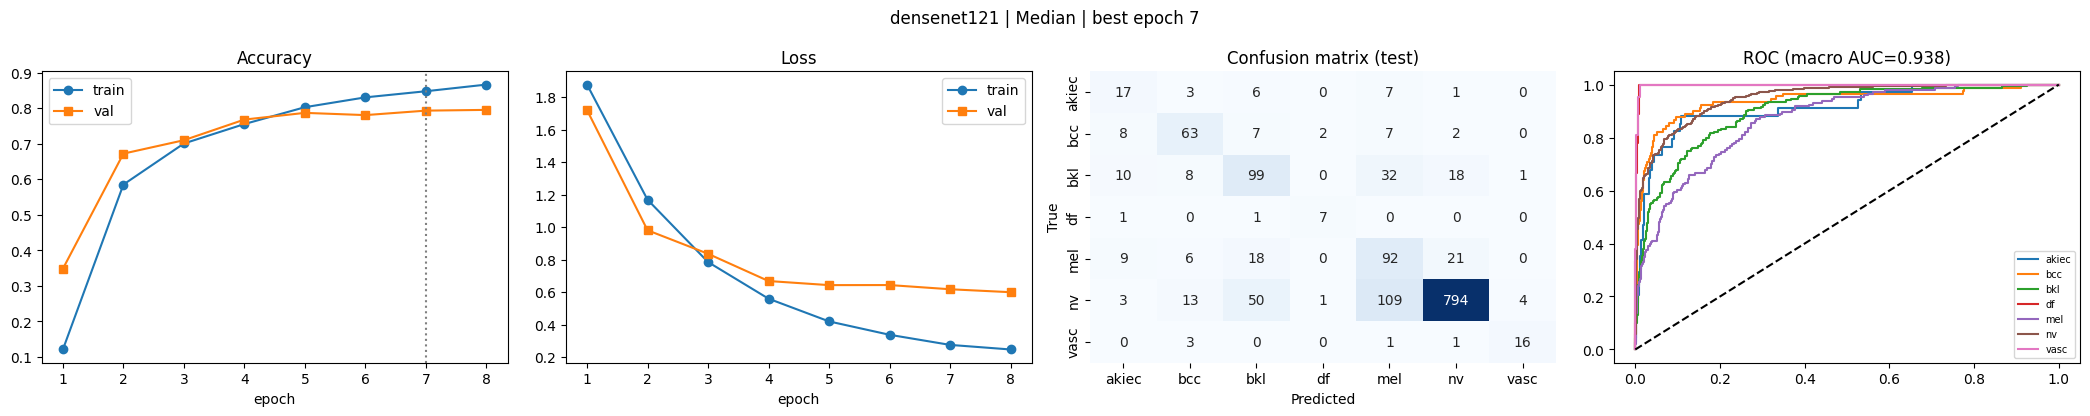

[12/18] efficientnet_b0  Median     acc=0.7058 macroF1=0.5278 balAcc=0.6078 AUC=0.9117 (55s)


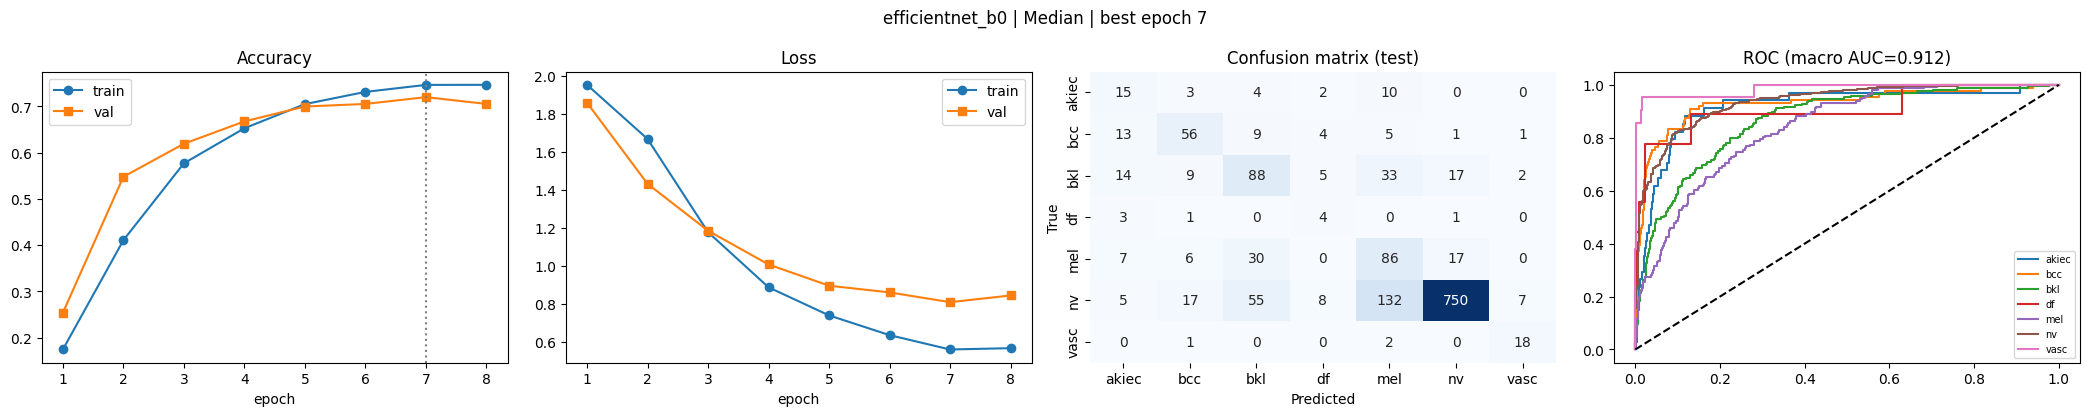

[13/18] resnet50         Sharpening acc=0.7814 macroF1=0.6723 balAcc=0.6861 AUC=0.9468 (78s)


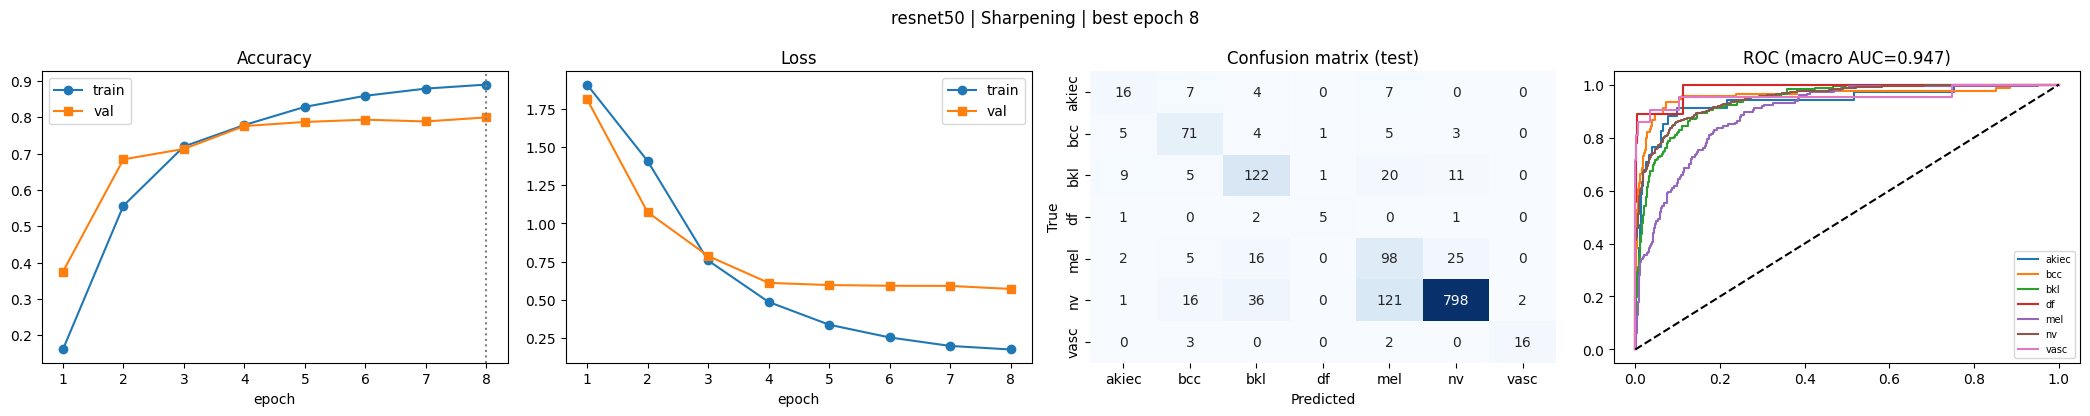

[14/18] densenet121      Sharpening acc=0.7689 macroF1=0.6363 balAcc=0.6618 AUC=0.9388 (98s)


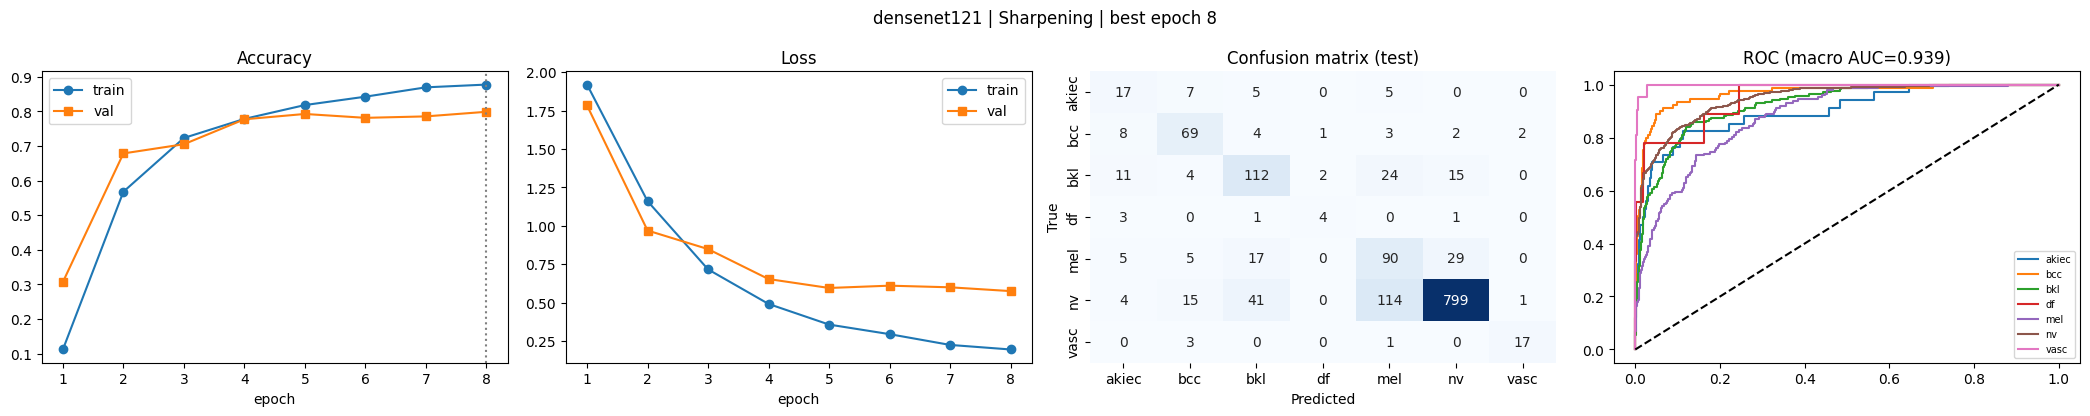

[15/18] efficientnet_b0  Sharpening acc=0.6808 macroF1=0.5224 balAcc=0.6306 AUC=0.9099 (54s)


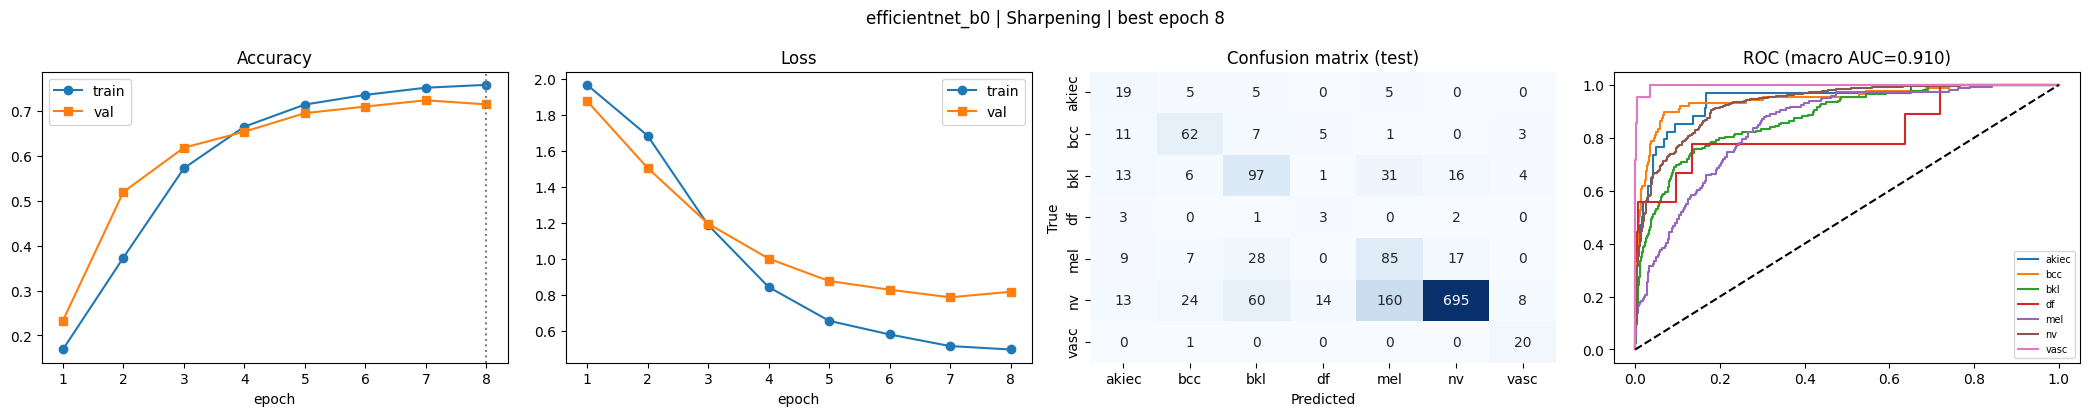

[16/18] resnet50         Sobel      acc=0.6308 macroF1=0.3936 balAcc=0.4804 AUC=0.8537 (78s)


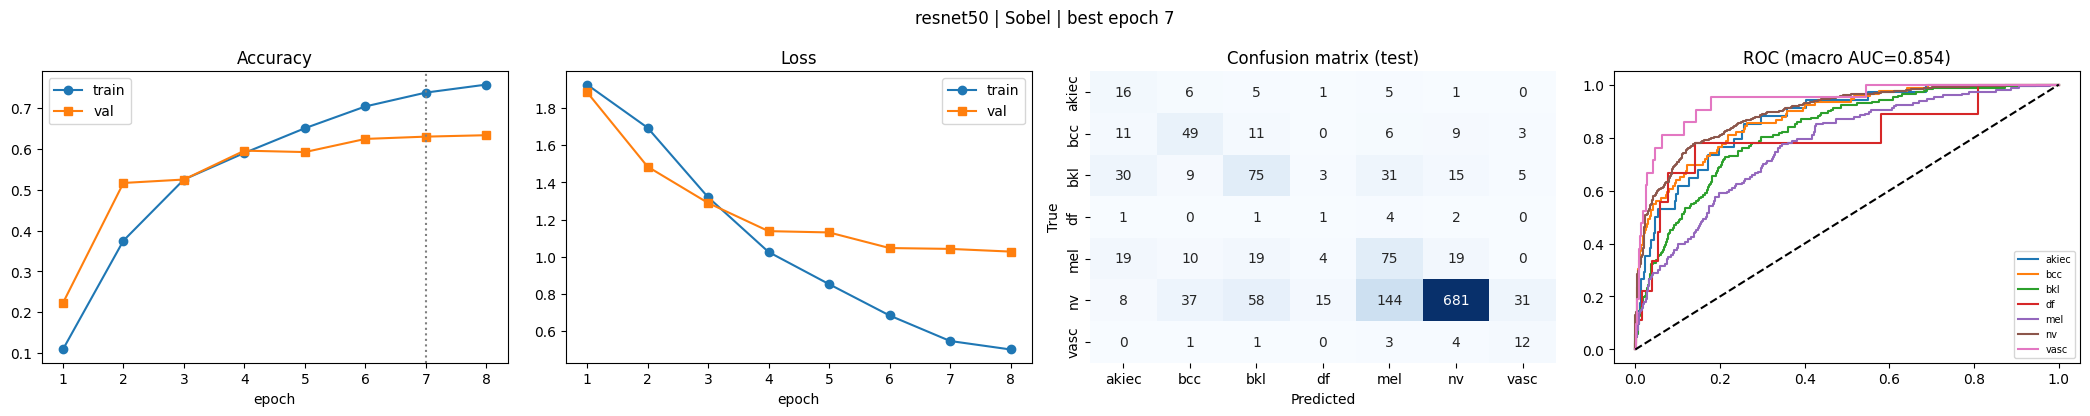

[17/18] densenet121      Sobel      acc=0.6343 macroF1=0.4232 balAcc=0.5399 AUC=0.8520 (98s)


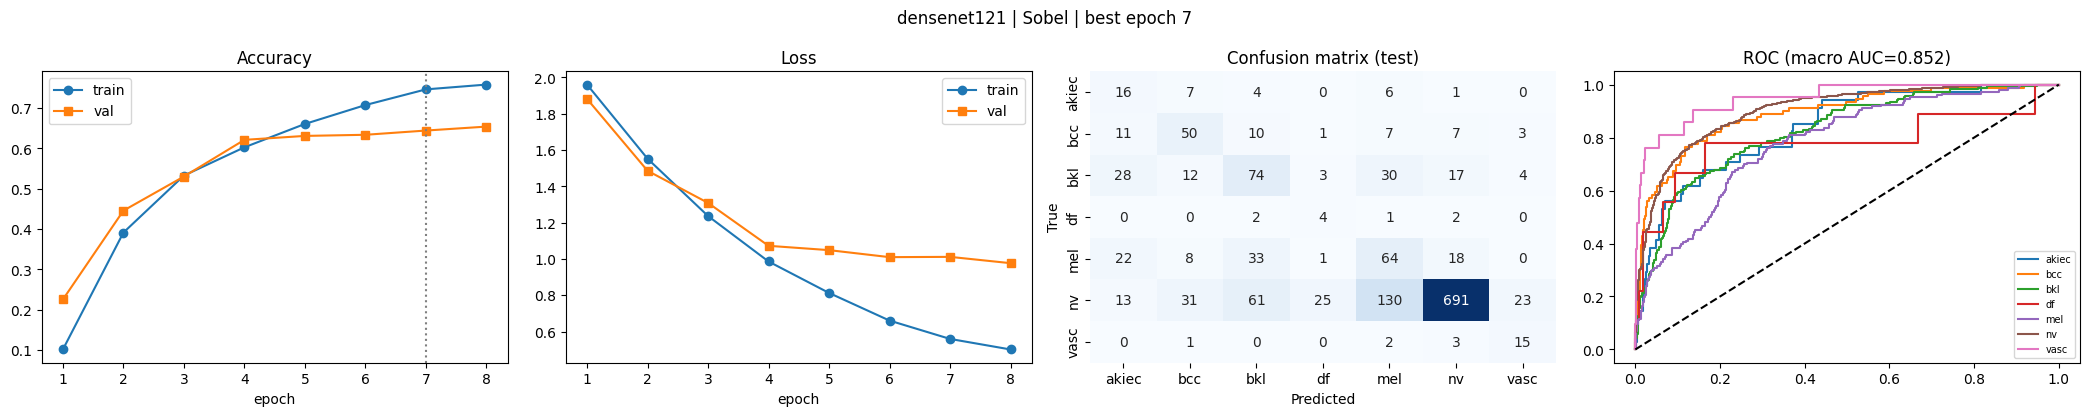

[18/18] efficientnet_b0  Sobel      acc=0.5496 macroF1=0.3438 balAcc=0.4939 AUC=0.8303 (54s)


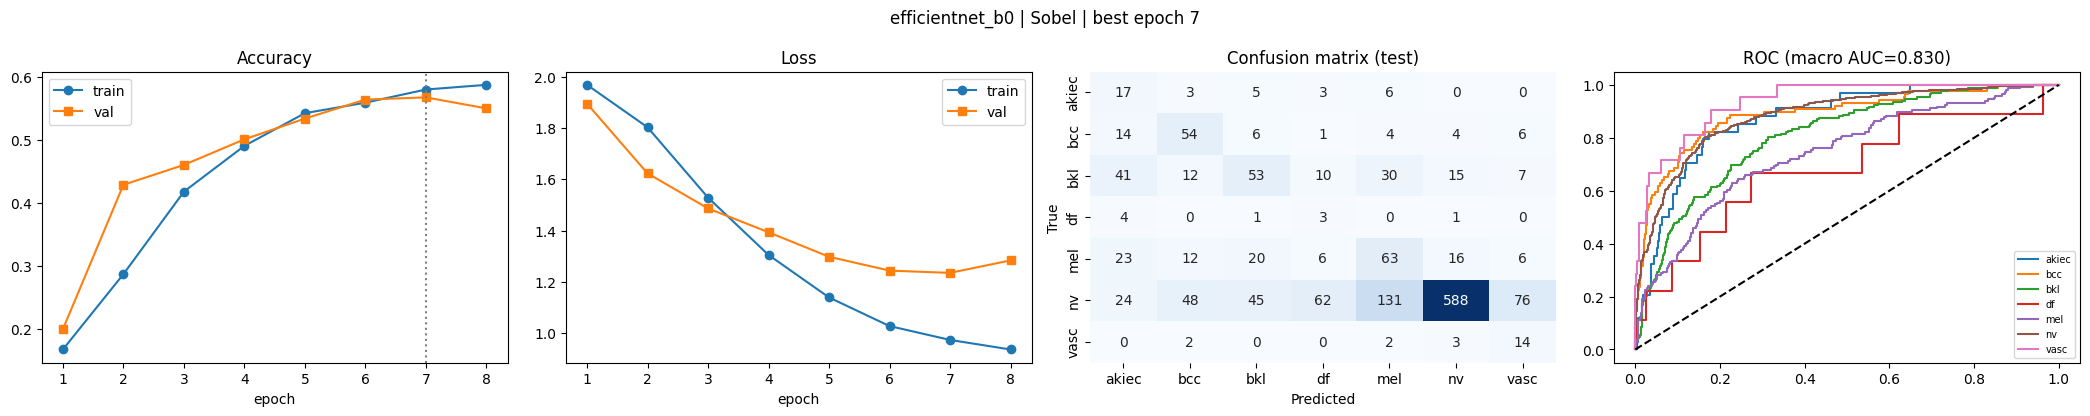

Total time: 24.6 min


In [9]:
results = []
yt_all = torch.tensor(y, device=dev)
t0 = time.time()
for filt in FILTERS:
    Xt = torch.from_numpy(filter_all(X, filt)).to(dev)
    for mn in MODEL_NAMES:
        s = time.time(); r = run_experiment(mn, filt, Xt, yt_all); results.append(r)
        m = r["metrics"]
        print(f"[{len(results):02d}/{len(FILTERS)*len(MODEL_NAMES)}] {mn:16s} {filt:10s} acc={m['Accuracy']:.4f} macroF1={m['MacroF1']:.4f} "
              f"balAcc={m['BalancedAcc']:.4f} AUC={m['AUC']:.4f} ({time.time()-s:.0f}s)")
        show_run(r)
    del Xt; torch.cuda.empty_cache()
print(f"Total time: {(time.time()-t0)/60:.1f} min")

## 7. Required comparison table

In [10]:
pretty = {"resnet50": "ResNet50", "densenet121": "DenseNet121", "efficientnet_b0": "EfficientNet-B0"}
rows = []
for r in results:
    rows.append({"Model": pretty.get(r["model"], r["model"]), "Filter": r["filter"], **{k: v for k, v in r["metrics"].items()}})
res = pd.DataFrame(rows).rename(columns={"F1": "F1-score", "MacroF1": "Macro-F1", "BalancedAcc": "Balanced Acc"})
res["Model"] = pd.Categorical(res.Model, [pretty.get(m, m) for m in MODEL_NAMES], ordered=True)
res["Filter"] = pd.Categorical(res.Filter, FILTERS, ordered=True)
res = res.sort_values(["Model", "Filter"]).reset_index(drop=True)
MET = ["Accuracy", "Precision", "Recall", "F1-score", "Macro-F1", "Balanced Acc", "AUC"]
display(res.style.format({m: "{:.4f}" for m in MET}).background_gradient(subset=["Macro-F1", "Balanced Acc"], cmap="YlGn"))
res.to_csv(f"{OUT_DIR}/comparison_table.csv", index=False)
print("Precision/Recall/F1-score = weighted average over classes; Macro-F1 = unweighted mean of per-class F1; AUC = macro one-vs-rest.")

,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Acc,AUC
0,ResNet50,No Filter,0.7800,0.8183,0.7800,0.7937,0.6042,0.6402,0.9315
1,ResNet50,Average,0.7550,0.8044,0.7550,0.7730,0.6103,0.6542,0.9287
2,ResNet50,Gaussian,0.7647,0.8133,0.7647,0.7819,0.6117,0.6421,0.9292
3,ResNet50,Median,0.7585,0.8103,0.7585,0.7772,0.6465,0.6730,0.9281
4,ResNet50,Sharpening,0.7814,0.8297,0.7814,0.7976,0.6723,0.6861,0.9468
5,ResNet50,Sobel,0.6308,0.7446,0.6308,0.6701,0.3936,0.4804,0.8537
6,DenseNet121,No Filter,0.7696,0.8132,0.7696,0.7848,0.6673,0.7061,0.9424
7,DenseNet121,Average,0.7273,0.7968,0.7273,0.7511,0.5917,0.6719,0.9330
8,DenseNet121,Gaussian,0.7495,0.7949,0.7495,0.7659,0.6359,0.6949,0.9297
9,DenseNet121,Median,0.7550,0.8069,0.7550,0.7737,0.6437,0.6832,0.9378


Precision/Recall/F1-score = weighted average over classes; Macro-F1 = unweighted mean of per-class F1; AUC = macro one-vs-rest.


## 8. Effect of filtering (change vs. unfiltered baseline)

,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,Balanced Acc,AUC
1,ResNet50,Average,-0.0250,-0.0140,-0.0250,-0.0207,+0.0062,+0.0140,-0.0028
2,ResNet50,Gaussian,-0.0153,-0.0050,-0.0153,-0.0118,+0.0075,+0.0019,-0.0024
3,ResNet50,Median,-0.0215,-0.0080,-0.0215,-0.0164,+0.0423,+0.0328,-0.0035
4,ResNet50,Sharpening,+0.0014,+0.0114,+0.0014,+0.0040,+0.0681,+0.0459,+0.0152
5,ResNet50,Sobel,-0.1492,-0.0737,-0.1492,-0.1236,-0.2106,-0.1598,-0.0778
7,DenseNet121,Average,-0.0423,-0.0164,-0.0423,-0.0338,-0.0756,-0.0342,-0.0094
8,DenseNet121,Gaussian,-0.0201,-0.0183,-0.0201,-0.0189,-0.0314,-0.0111,-0.0127
9,DenseNet121,Median,-0.0146,-0.0063,-0.0146,-0.0111,-0.0237,-0.0229,-0.0046
10,DenseNet121,Sharpening,-0.0007,+0.0019,-0.0007,+0.0007,-0.0310,-0.0443,-0.0037
11,DenseNet121,Sobel,-0.1353,-0.0691,-0.1353,-0.1118,-0.2441,-0.1662,-0.0904


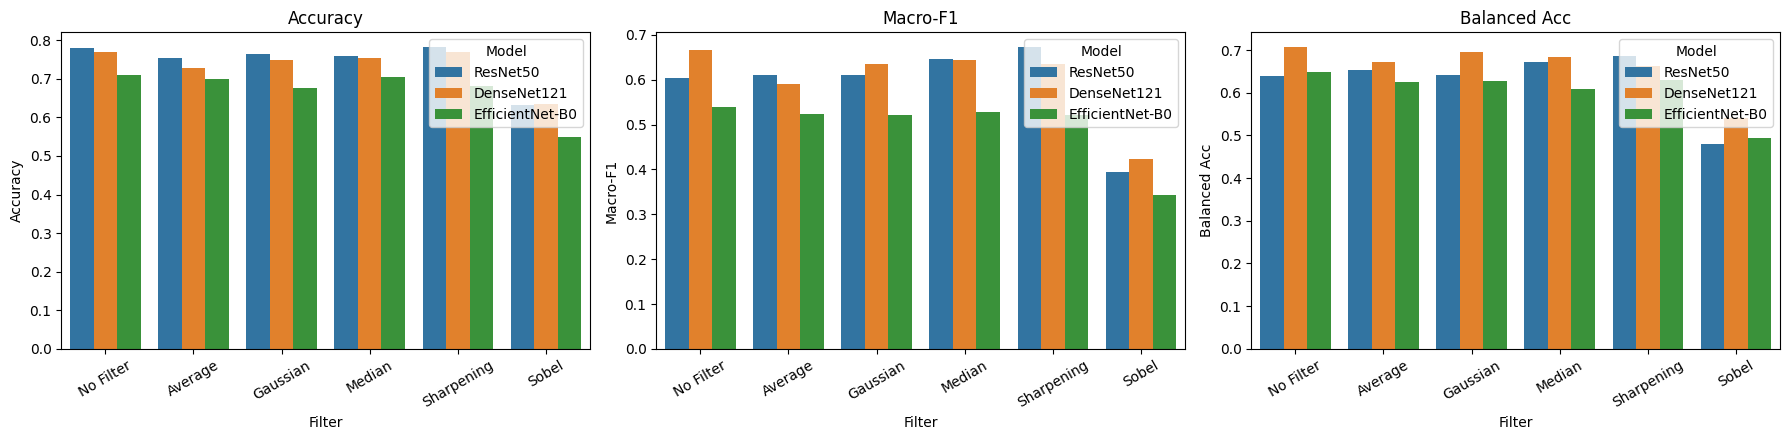

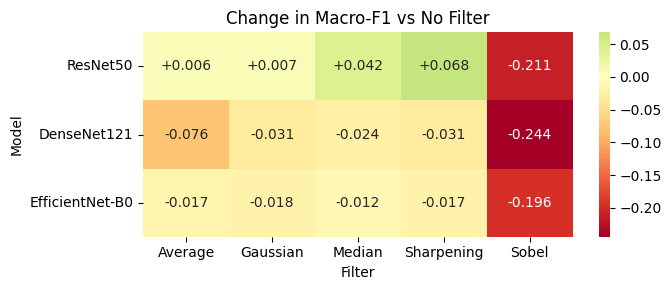

In [11]:
base = res[res.Filter == "No Filter"].set_index("Model")[MET]
delta = res.copy()
for m in MET: delta[m] = res[m].values - base.loc[res.Model.astype(str).values, m].values
delta_f = delta[delta.Filter != "No Filter"]
display(delta_f.style.format({m: "{:+.4f}" for m in MET}).background_gradient(subset=["Macro-F1", "Balanced Acc"], cmap="RdYlGn", vmin=-0.2, vmax=0.2))

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
for a, m in zip(ax, ["Accuracy", "Macro-F1", "Balanced Acc"]):
    sns.barplot(data=res, x="Filter", y=m, hue="Model", ax=a); a.set_title(m); a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/figs/metric_comparison.png", dpi=150); plt.show()

hm = delta_f.pivot(index="Model", columns="Filter", values="Macro-F1").astype(float)
plt.figure(figsize=(7, 3)); sns.heatmap(hm, annot=True, fmt="+.3f", cmap="RdYlGn", center=0); plt.title("Change in Macro-F1 vs No Filter")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/figs/delta_macroF1.png", dpi=150); plt.show()

## 9. Per-class precision / recall / F1 and which classes are most affected


=== ResNet50: per-class F1 ===


Class,akiec,bcc,bkl,df,mel,nv,vasc
Filter,,,,,,,
No Filter,0.466,0.667,0.611,0.353,0.496,0.898,0.739
Average,0.487,0.663,0.570,0.381,0.456,0.878,0.837
Gaussian,0.431,0.645,0.628,0.500,0.458,0.885,0.735
Median,0.400,0.644,0.616,0.625,0.453,0.877,0.909
Sharpening,0.471,0.724,0.693,0.625,0.491,0.881,0.821
Sobel,0.269,0.488,0.444,0.061,0.362,0.799,0.333


=== ResNet50: per-class Recall ===


Class,akiec,bcc,bkl,df,mel,nv,vasc
Filter,,,,,,,
No Filter,0.500,0.708,0.720,0.333,0.568,0.842,0.810
Average,0.559,0.708,0.583,0.444,0.610,0.818,0.857
Gaussian,0.412,0.663,0.685,0.444,0.610,0.824,0.857
Median,0.471,0.652,0.655,0.556,0.610,0.816,0.952
Sharpening,0.471,0.798,0.726,0.556,0.671,0.819,0.762
Sobel,0.471,0.551,0.446,0.111,0.514,0.699,0.571


=== ResNet50: per-class Precision ===


...

Class,akiec,bcc,bkl,df,mel,nv,vasc
Filter,,,,,,,
No Filter,0.379,0.667,0.555,0.323,0.417,0.842,0.596
Average,0.277,0.602,0.506,0.312,0.416,0.845,0.704
Gaussian,0.340,0.588,0.501,0.312,0.379,0.826,0.706
Median,0.330,0.615,0.497,0.250,0.415,0.852,0.735
Sharpening,0.373,0.639,0.530,0.188,0.397,0.816,0.714
Sobel,0.217,0.491,0.356,0.064,0.330,0.735,0.215


=== EfficientNet-B0: per-class Recall ===


Class,akiec,bcc,bkl,df,mel,nv,vasc
Filter,,,,,,,
No Filter,0.529,0.742,0.560,0.556,0.596,0.755,0.810
Average,0.382,0.663,0.524,0.556,0.582,0.759,0.905
Gaussian,0.529,0.618,0.548,0.556,0.555,0.726,0.857
Median,0.441,0.629,0.524,0.444,0.589,0.770,0.857
Sharpening,0.559,0.697,0.577,0.333,0.582,0.714,0.952
Sobel,0.500,0.607,0.315,0.333,0.432,0.604,0.667


=== EfficientNet-B0: per-class Precision ===


Class,akiec,bcc,bkl,df,mel,nv,vasc
Filter,,,,,,,
No Filter,0.295,0.606,0.550,0.227,0.321,0.953,0.472
Average,0.217,0.551,0.489,0.217,0.323,0.954,0.576
Gaussian,0.250,0.561,0.462,0.217,0.288,0.958,0.600
Median,0.263,0.602,0.473,0.174,0.321,0.954,0.643
Sharpening,0.279,0.590,0.490,0.130,0.301,0.952,0.571
Sobel,0.138,0.412,0.408,0.035,0.267,0.938,0.128


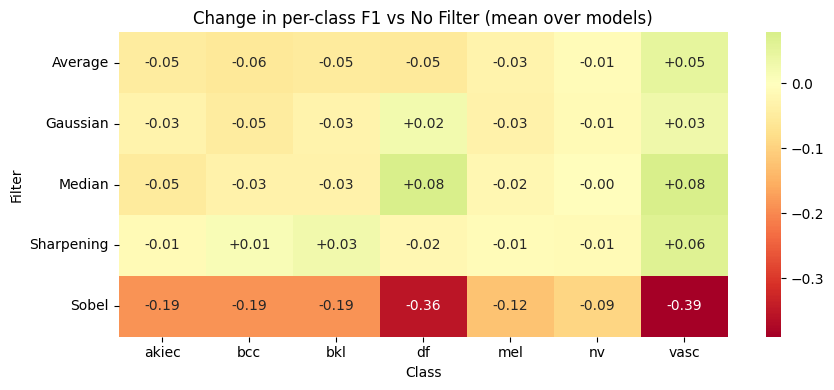

In [12]:
pc = []
for r in results:
    for c in CLASSES:
        d = r["per_class"][c]
        pc.append(dict(Model=pretty.get(r["model"], r["model"]), Filter=r["filter"], Class=c, Precision=d["precision"],
                       Recall=d["recall"], F1=d["f1-score"], Support=d["support"], AUC=r["per_class_auc"][c]))
pc = pd.DataFrame(pc); pc.to_csv(f"{OUT_DIR}/per_class_metrics.csv", index=False)
for mn in pc.Model.unique():
    print(f"\n=== {mn}: per-class F1 ==="); display(pc[pc.Model == mn].pivot(index="Filter", columns="Class", values="F1").reindex(FILTERS).round(3))
    print(f"=== {mn}: per-class Recall ==="); display(pc[pc.Model == mn].pivot(index="Filter", columns="Class", values="Recall").reindex(FILTERS).round(3))
    print(f"=== {mn}: per-class Precision ==="); display(pc[pc.Model == mn].pivot(index="Filter", columns="Class", values="Precision").reindex(FILTERS).round(3))

pcb = pc[pc.Filter == "No Filter"].set_index(["Model", "Class"]).F1
pc["dF1"] = pc.F1.values - pcb.loc[list(zip(pc.Model, pc.Class))].values
cls_delta = pc[pc.Filter != "No Filter"].groupby(["Filter", "Class"]).dF1.mean().unstack().reindex(FILTERS[1:])
plt.figure(figsize=(9, 4)); sns.heatmap(cls_delta, annot=True, fmt="+.2f", cmap="RdYlGn", center=0)
plt.title("Change in per-class F1 vs No Filter (mean over models)"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figs/per_class_delta.png", dpi=150); plt.show()

## 10. Automatic answers derived from YOUR results

In [13]:
print("Q1. Models used:", ", ".join(pretty.get(m, m) for m in MODEL_NAMES), "(confirm these match your Lab 1 ranking)\n")
print("Q2. Change in Macro-F1 / Balanced Acc / Accuracy vs baseline, per model:")
for mn in delta_f.Model.cat.categories:
    d = delta_f[delta_f.Model == mn]
    best_f = d.loc[d["Macro-F1"].idxmax()]; worst_f = d.loc[d["Macro-F1"].idxmin()]
    print(f"  {mn}: baseline macro-F1={base.loc[mn,'Macro-F1']:.3f}; best filter={best_f.Filter} ({best_f['Macro-F1']:+.3f}), "
          f"worst filter={worst_f.Filter} ({worst_f['Macro-F1']:+.3f})")
mag = delta_f.assign(a=delta_f["Macro-F1"].abs()).groupby("Filter").a.mean().sort_values(ascending=False)
print("\nQ3. Mean |change in Macro-F1| by filter (largest first):"); print(mag.round(4).to_string())
print(f"  -> Greatest change: {mag.index[0]}")
print("\nQ4. Consistency of direction (sign of change in Macro-F1) across models:")
for f in FILTERS[1:]:
    s = delta_f[delta_f.Filter == f]["Macro-F1"].astype(float).values
    print(f"  {f:10s}: {np.round(s,3)} -> {'CONSISTENT (' + ('improves' if (s>0).all() else 'hurts') + ')' if (s>0).all() or (s<0).all() else 'INCONSISTENT'}")
print("\nQ5. Average effect of each filter (mean over models):")
print(delta_f.groupby("Filter")[["Macro-F1", "Balanced Acc", "Accuracy"]].mean().reindex(FILTERS[1:]).round(4).to_string())
print("\nQ6. Most affected classes (mean |change in F1| over filters and models):")
print(pc[pc.Filter != "No Filter"].assign(a=lambda d: d.dF1.abs()).groupby("Class").a.mean().sort_values(ascending=False).round(4).to_string())

Q1. Models used: ResNet50, DenseNet121, EfficientNet-B0 (confirm these match your Lab 1 ranking)

Q2. Change in Macro-F1 / Balanced Acc / Accuracy vs baseline, per model:
  ResNet50: baseline macro-F1=0.604; best filter=Sharpening (+0.068), worst filter=Sobel (-0.211)
  DenseNet121: baseline macro-F1=0.667; best filter=Median (-0.024), worst filter=Sobel (-0.244)
  EfficientNet-B0: baseline macro-F1=0.540; best filter=Median (-0.012), worst filter=Sobel (-0.196)

Q3. Mean |change in Macro-F1| by filter (largest first):
Filter
Sobel         0.2169
Sharpening    0.0389
Average       0.0329
Median        0.0260
Gaussian      0.0190
No Filter        NaN
  -> Greatest change: Sobel

Q4. Consistency of direction (sign of change in Macro-F1) across models:
  Average   : [ 0.006 -0.076 -0.017] -> INCONSISTENT
  Gaussian  : [ 0.007 -0.031 -0.018] -> INCONSISTENT
  Median    : [ 0.042 -0.024 -0.012] -> INCONSISTENT
  Sharpening: [ 0.068 -0.031 -0.017] -> INCONSISTENT
  Sobel     : [-0.211 -0.244

## 11. Convolution vs. correlation (demo)

In [14]:
from scipy.signal import correlate2d, convolve2d
a = np.arange(25).reshape(5, 5).astype(float); k = np.array([[1, 2, 0], [0, 1, 0], [0, 0, 0]], float)   # asymmetric kernel
corr = correlate2d(a, k, mode="valid"); conv = convolve2d(a, k, mode="valid"); conv_as_corr = correlate2d(a, np.flip(k), mode="valid")
print("Correlation:\n", corr, "\nConvolution:\n", conv, "\nCorrelation with 180-degree flipped kernel == convolution:", np.allclose(conv, conv_as_corr))
print("Symmetric kernels (mean, Gaussian, Sobel up to sign) give the same result either way.")
print("Note: cv2.filter2D and CNN layers (nn.Conv2d) actually compute CORRELATION.")

Correlation:
 [[ 8. 12. 16.]
 [28. 32. 36.]
 [48. 52. 56.]] 
Convolution:
 [[40. 44. 48.]
 [60. 64. 68.]
 [80. 84. 88.]] 
Correlation with 180-degree flipped kernel == convolution: True
Symmetric kernels (mean, Gaussian, Sobel up to sign) give the same result either way.
Note: cv2.filter2D and CNN layers (nn.Conv2d) actually compute CORRELATION.


## 12. Discussion (theory answers - adapt the wording and add your own numbers from Section 10)

**Q7. Why might smoothing (Average/Gaussian/Median) remove useful lesion information?**
Dermoscopic diagnosis depends on fine structures: pigment network, dots/globules, streaks, border irregularity, and colour texture.
These are high-spatial-frequency details. Mean and Gaussian filters are low-pass filters that attenuate them and blur lesion borders
(border sharpness helps separate melanoma from nevi). The median filter preserves edges better and removes hair/noise, but with a large
window it erases small dots and thin network lines. Smoothing helps only if the noise/hair it removes matters more than the detail it destroys.
A pretrained CNN already learns its own denoising through its early layers, so extra smoothing is often redundant or harmful.

**Q8. Why might sharpening or edge detection help or hurt?**
*Help:* sharpening (high-boost) amplifies borders, pigment network and texture, which can make discriminative structure more salient, and can
compensate for blur from resizing. *Hurt:* it also amplifies noise, hair and specular artefacts and can create halos. Sobel keeps only the
gradient magnitude of the grayscale image, so **colour (a key ABCD/dermoscopy cue) is discarded** and the image is far from the ImageNet
distribution the model was pretrained on, so the pretrained features transfer less well. Sobel therefore typically causes the largest drop,
but it can still work reasonably where shape/texture is enough.

**Q9. Convolution vs. correlation?**
Both slide a kernel over the image and sum element-wise products. In convolution the kernel is first flipped by 180 degrees
(rows and columns): (f*g)(x,y) = sum f(x-i,y-j) g(i,j). Correlation uses the kernel unflipped: sum f(x+i,y+j) g(i,j).
The results are identical for symmetric kernels (mean, Gaussian), and differ (sign/orientation) for asymmetric ones (Sobel, directional
sharpening). Convolution is commutative and associative and is the foundation of linear systems theory and the convolution theorem;
correlation is used for template matching. Deep-learning "convolution" layers are implemented as correlation, because the kernel is
learned, so flipping makes no difference.

**Q10. Classical image processing vs. deep-learning feature extraction?**
Classical filters are fixed, hand-designed convolution kernels chosen from prior knowledge (low-pass, high-pass, gradient). A CNN uses the same
operation but **learns its kernels from data**; the first layers typically converge to Gabor-like, edge, blob and colour filters, i.e. they
reproduce and generalise Sobel/Gaussian-type operators, and deeper layers combine them into lesion-specific patterns. Consequently, applying
a fixed filter before a CNN either duplicates what the network learns (no gain) or removes information the network could have used
(loss), which is why pre-filtering rarely gives consistent gains for fine-tuned pretrained models. Classical processing stays useful for
well-motivated tasks such as hair removal, illumination/colour correction and resizing, whereas the network handles feature extraction.
Your results (Sections 7-10) are the evidence: state whether the changes were small/inconsistent (network is robust) or large (input
distribution mismatch, e.g. Sobel).

## 13. Save everything (download zip)

In [15]:
zp = "/content/lab02_results.zip"
with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(OUT_DIR):
        for f in files:
            if not f.endswith(".pkl"): z.write(os.path.join(root, f), os.path.relpath(os.path.join(root, f), OUT_DIR))
print("Saved:", zp)
try:
    from google.colab import files; files.download(zp)
except Exception: pass

Saved: /content/lab02_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>